# T2 AC Stark Shift

Coupler spectroscopy probed via the manipulate channel.
Sequence: prep M1 in Fock |1>, sweep a const probe on the manipulate DAC,
swap |1> back to qubit |e> (f0-g1 pi + e0-f0 pi), then measure.

# Import

In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from copy import deepcopy

import experiments as meas
from experiments.MM_dual_rail_base import MM_dual_rail_base

from slab import AttrDict
from experiments import MultimodeStation, CharacterizationRunner, SweepRunner

from job_server import JobClient
from job_server.database import get_database
from job_server.config_versioning import ConfigVersionManager

# Initialize database and config manager
db = get_database()
config_dir = 'D:/python/multimode_expts/configs'
config_manager = ConfigVersionManager(config_dir)

# Initialize job client (handle submitting and waiting for jobs)
client = JobClient()

# Check server health
health = client.health_check()
print(f"Server status: {health['status']}")
print(f"Pending jobs: {health['pending_jobs']}")

user = "seb"
print("Welcome", user)


station = MultimodeStation(
    user=user,
    experiment_name="260420_T2_AC_stark",
)

active_reset_dict = {
    'active_reset': True,
    'ef_reset': True,
    'storage_reset': False,
    'coupler_reset': False,
    'pre_selection_reset': True,
    'man_reset': False,
    'use_qubit_man_reset': True,
    'pre_selection_parity': True,
}

USE_QUEUE = True
mm_base_calib = MM_dual_rail_base(station.hardware_cfg, station.soc)

# Coupler spectroscopy (pulse probe via manipulate channel)

In [ ]:
# ============================================
# Pulse-probe coupler spectroscopy
# prep M1 |1>  ->  swept const probe on man_ch  ->  swap |1> -> |e>  ->  readout
# ============================================

# 1. Defaults
coupler_spec_defaults = AttrDict(dict(
    # Frequency sweep (absolute MHz; manipulate DAC has no mixer)
    start=4000.0,        # MHz
    step=0.5,            # MHz
    expts=201,           # number of points -> spans 4000..4100 MHz
    # Probe pulse
    length=5.0,          # us (const pulse)
    gain=500,            # DAC units
    # Averaging
    reps=200,
    rounds=1,
    # Mode / qubit selection
    qubits=[0],
    man_mode_no=1,       # manipulate mode used for prep + swap-out
    # Optional user prepulse (gate-list format consumed by custom_pulse)
    coupler_f=False,  # whether to apply a coupler pulse at the start of the sequence (for testing)
    prepulse=False,
    pre_sweep_pulse=None,
    # Reset
    active_reset=False,
))


# 2. Optional postprocessor
def coupler_spec_postproc(station, expt):
    """Fit + display the spectroscopy trace."""
    expt.analyze(fit=True)
    expt.display(fit=True)
    return None


# 3. Runner
coupler_spec_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.PulseProbeCouplerSpectroscopyExperiment,
    default_expt_cfg=coupler_spec_defaults,
    postprocessor=coupler_spec_postproc,
    job_client=client,
    use_queue=USE_QUEUE,
)

In [ ]:
f_start = 4000
f_stop = 4150
expts = 101
step = (f_stop - f_start) / (expts - 1)

In [ ]:
# 4. Execute
coupler_spec_expt = coupler_spec_runner.execute(
    start=f_start,
    step=step,
    expts=expts,
    length=50,
    gain=5000,
    reps=200,
    rounds=1,
    coupler_f=False,
    go_kwargs=dict(analyze=False, display=False),
    # **active_reset_dict,
)

# If using queue, analyze/display manually
if USE_QUEUE:
    coupler_spec_expt.analyze(fit=True)
    coupler_spec_expt.display(fit=True)

In [ ]:
f_coupler = coupler_spec_expt.data['fit_avgi'][2]
print(f"Coupler frequency from spectroscopy: {f_coupler:.3f} MHz")

# 2D sweep of probe frequency and power

In [ ]:
# --- Outer sweep config ---
gain_start = 2000
gain_stop  = 10000
gain_npts  = 11

# Inner (per-point) spectroscopy window — override coupler_spec_defaults
inner_f_start = 4050
inner_f_stop  = 4150
inner_expts   = 401
inner_step    = (inner_f_stop - inner_f_start) / (inner_expts - 1)

FIT_CHANNEL = 'avgi'   # 'avgi', 'avgq', or 'amps'
SIGN        = 1        # flip to -1 if peak is negative in that channel

In [ ]:
# --- SweepRunner: outer = probe gain, inner = coupler spectroscopy ---
coupler_spec_vs_gain_runner = SweepRunner(
    station=station,
    ExptClass=meas.PulseProbeCouplerSpectroscopyExperiment,
    default_expt_cfg=coupler_spec_defaults,
    sweep_param='gain',
    job_client=client,
    use_queue=USE_QUEUE,
)

coupler_spec_vs_gain = coupler_spec_vs_gain_runner.execute(
    sweep_start=gain_start,
    sweep_stop=gain_stop,
    sweep_npts=gain_npts,
    start=inner_f_start, step=inner_step, expts=inner_expts,
    length=5.0,
    reps=400, rounds=1,
    coupler_f=False,
)

In [ ]:
from copy import deepcopy
import numpy as np
import matplotlib.pyplot as plt
import fitting.fitting as fitter

FIT_CHANNEL = 'avgi'   # 'avgi', 'avgq', or 'amps'
SIGN        = 1        # flip to -1 if peak is negative in that channel

gains   = np.asarray(coupler_spec_vs_gain.data['gain_sweep'])
xpts_2d = np.asarray(coupler_spec_vs_gain.data['xpts'])
y_2d    = np.asarray(coupler_spec_vs_gain.data[FIT_CHANNEL])

centers = np.full(len(gains), np.nan)
hwhms   = np.full(len(gains), np.nan)
fit_params = []

# Grid of subplots: one per gain slice.
ncols = min(4, len(gains))
nrows = int(np.ceil(len(gains) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows),
                         squeeze=False)

for i, (x, y, g) in enumerate(zip(xpts_2d, y_2d, gains)):
    ax = axes[i // ncols, i % ncols]
    ax.plot(x, y, 'o', ms=3, label='data')
    try:
        p, _ = fitter.fitlor(x, SIGN * y)
        fit_params.append(p)
        centers[i] = p[2]
        hwhms[i]   = abs(p[3])
        x_fine = np.linspace(x.min(), x.max(), 400)
        ax.plot(x_fine, SIGN * fitter.lorfunc(x_fine, *p), '-',
                label=f'x0={p[2]:.3f}, HWHM={abs(p[3]):.3f}')
    except Exception as e:
        fit_params.append(None)
        print(f'  [{i}] gain={g:.0f}: fit failed ({e})')
    ax.set_title(f'gain = {g:.0f}')
    ax.set_xlabel('freq [MHz]'); ax.set_ylabel(FIT_CHANNEL)
    ax.legend(fontsize=8)

# Hide any unused axes
for j in range(len(gains), nrows * ncols):
    axes[j // ncols, j % ncols].set_visible(False)

plt.tight_layout(); plt.show()

# Summary trend
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(gains, centers, 'o-'); axes[0].set_xlabel('probe gain [DAC]')
axes[0].set_ylabel('Lorentzian center [MHz]')
axes[1].plot(gains, hwhms, 'o-');   axes[1].set_xlabel('probe gain [DAC]')
axes[1].set_ylabel('Lorentzian HWHM [MHz]')
plt.tight_layout(); plt.show()

print('centers [MHz]:', centers)
print('HWHMs   [MHz]:', hwhms)


In [ ]:
T1_us = 50.0   # independent T1 estimate [us]

fwhms_MHz = 2.0 * np.asarray(hwhms)
A_arr     = np.asarray(gains, dtype=float)
mask      = np.isfinite(fwhms_MHz) & (fwhms_MHz > 0)
x = A_arr[mask] ** 2              # DAC^2
y = fwhms_MHz[mask] ** 2          # MHz^2

# Linear fit y = m*x + b with covariance.
(m_slope, b_intercept), V = np.polyfit(x, y, 1, cov=True)
sig_m  = float(np.sqrt(V[0, 0]))
sig_b  = float(np.sqrt(V[1, 1]))
cov_mb = float(V[0, 1])

# --- Plot the linearized fit ---
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(x, y, 'o', ms=5, label='data')
x_line = np.linspace(0.0, float(x.max()), 200)
ax.plot(x_line, m_slope * x_line + b_intercept, 'k--', lw=1,
        label=f'y = ({m_slope:.3e}±{sig_m:.1e}) x + ({b_intercept:.3e}±{sig_b:.1e})')
ax.set_xlabel(r'$A^2$   [DAC$^2$]')
ax.set_ylabel(r'FWHM$^2$   [MHz$^2$]')
ax.set_title('Power-broadening linearization')
ax.legend()
plt.tight_layout(); plt.show()

# --- Extract T2 and k (with guards + error propagation) ---
if b_intercept <= 0:
    print(f'WARNING: intercept is non-positive ({b_intercept:.3e} MHz^2) '
          f'-> T2 cannot be extracted.')
    T2_us = np.nan; T2_err_us = np.nan
else:
    T2_us     = 1.0 / (np.pi * np.sqrt(b_intercept))           # us
    # dT2/db = -T2 / (2b)
    T2_err_us = abs(T2_us / (2.0 * b_intercept)) * sig_b

if m_slope <= 0 or not np.isfinite(T2_us):
    print(f'WARNING: cannot extract k (slope={m_slope:.3e}, T2={T2_us}).')
    k_rad = np.nan; k_err = np.nan
else:
    # k = sqrt(pi/T1) * m^(1/2) * b^(-1/4)
    k_rad = np.sqrt(np.pi / T1_us) * np.sqrt(m_slope) * b_intercept ** (-0.25)
    # dk/dm = k/(2m);  dk/db = -k/(4b)
    dkdm = k_rad / (2.0 * m_slope)
    dkdb = -k_rad / (4.0 * b_intercept)
    var_k = (dkdm ** 2) * V[0, 0] + (dkdb ** 2) * V[1, 1] \
            + 2.0 * dkdm * dkdb * V[0, 1]
    k_err = float(np.sqrt(max(var_k, 0.0)))

# --- Summary ---
A_max_used   = float(A_arr[mask].max())
Omega_pk_MHz = k_rad * A_max_used / (2.0 * np.pi) if np.isfinite(k_rad) else np.nan
Omega_pk_err = (k_err * A_max_used / (2.0 * np.pi)
                if np.isfinite(k_err) else np.nan)

print('Power-broadening fit:')
print(f'  intercept b = {b_intercept:.4e} ± {sig_b:.2e} MHz^2')
print(f'  slope     m = {m_slope:.4e} ± {sig_m:.2e} MHz^2/DAC^2')
print(f'  cov(m, b)   = {cov_mb:.3e}')
print()
print(f'  T2 = {T2_us*1e3:.2f} ± {T2_err_us*1e3:.2f} ns   (from intercept, T1-independent)')
print(f'  Assuming T1 = {T1_us:.1f} us:')
print(f'    k = {k_rad:.4g} ± {k_err:.2g} rad/us/DAC')
print(f'    Omega_pk(A = {A_max_used:.0f}) = {Omega_pk_MHz:.3f} ± {Omega_pk_err:.3f} MHz')


In [ ]:
from scipy.optimize import curve_fit

T1_us = 50.0

fwhms_MHz = 2.0 * np.asarray(hwhms)
A_arr     = np.asarray(gains, dtype=float)
mask      = np.isfinite(fwhms_MHz) & (fwhms_MHz > 0)
A_fit = A_arr[mask]; F_fit = fwhms_MHz[mask]


def fwhm_model(A, T2, k):
    return (1.0 / np.pi) * np.sqrt(1.0 / T2**2 + (k * A) ** 2 * T1_us / T2)


# Seeds from a quick linearized fit.
m0, b0 = np.polyfit(A_fit ** 2, F_fit ** 2, 1)
T2_seed = 1.0 / (np.pi * np.sqrt(max(b0, 1e-6)))
k_seed  = np.pi * np.sqrt(max(m0, 1e-12) * T2_seed / T1_us)

popt, pcov = curve_fit(
    fwhm_model, A_fit, F_fit,
    p0=[T2_seed, k_seed],
    bounds=([1e-4, 0.0], [np.inf, np.inf]),
    maxfev=20000,
)
T2_us, k_rad       = popt
T2_err_us, k_err   = np.sqrt(np.diag(pcov))

# Per-point saturation parameter s0 = (Omega^2) T1 T2 = (kA)^2 T1 T2.
s0 = (k_rad * A_fit) ** 2 * T1_us * T2_us

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
A_line = np.linspace(0, A_fit.max() * 1.05, 400)

ax = axes[0]
ax.plot(A_fit, F_fit, 'o', ms=5, label='data')
ax.plot(A_line, fwhm_model(A_line, *popt), 'k-', lw=1, label='fit')
ax.axhline(1.0 / (np.pi * T2_us), color='C2', ls=':', lw=1,
           label=fr'$1/(\pi T_2)$ floor = {1/(np.pi*T2_us):.2f} MHz')
ax.plot(A_line, (k_rad * A_line / np.pi) * np.sqrt(T1_us / T2_us),
        color='C3', ls=':', lw=1, label=r'$(kA/\pi)\sqrt{T_1/T_2}$ asymptote')
ax.set_xlabel('A [DAC]'); ax.set_ylabel('FWHM [MHz]')
ax.set_title('Power broadening (linear axes)')
ax.legend(fontsize=8)

ax = axes[1]
ax.semilogy(A_fit, s0, 'o-')
ax.axhline(1.0, color='k', ls='--', lw=0.8, label=r'$s_0 = 1$ (crossover)')
ax.set_xlabel('A [DAC]'); ax.set_ylabel(r'$s_0 = \Omega^2 T_1 T_2$')
ax.set_title('Saturation parameter per point')
ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

A_max_used   = float(A_fit.max())
Omega_pk_MHz = k_rad * A_max_used / (2.0 * np.pi)
Omega_pk_err = k_err   * A_max_used / (2.0 * np.pi)

print('Nonlinear fit of FWHM vs A:')
print(f'  T2 = {T2_us*1e3:.2f} ± {T2_err_us*1e3:.2f} ns')
print(f'  k  = {k_rad:.4g} ± {k_err:.2g} rad/us/DAC  (assuming T1={T1_us} us)')
print(f'  Omega_pk(A={A_max_used:.0f}) = {Omega_pk_MHz:.3f} ± {Omega_pk_err:.3f} MHz')
print(f'  s0(A_min) = {s0.min():.3f}   s0(A_max) = {s0.max():.3f}')
print()
print('  If s0 < 1 everywhere -> you are in low-power regime; T2 is well-pinned,')
print('  k depends on the few points where s0 is appreciable. The fact that the')
print('  smallest-gain FWHM^2 nearly equals the intercept is the tell.')


# 2D sweep: coupler spectrum vs. Yoko-coupler DC current

Outer sweep is the Yoko-coupler current. We mirror the JPA-calibration pattern
from `single_qubit_autocalibrate_v2.ipynb`: a notebook-side loop over currents,
and inside the loop each point is submitted as a queued job via
`CharacterizationRunner.run()` (so no `run_local`). Data from each returned
child experiment is accumulated into a manually-built mother experiment for
2D plotting / saving.

Note: `worker.py` already auto-ramps `station.yoko_coupler` to
`cfg.expt.coupler_current` before each job, so passing `coupler_current=...`
to `runner.run()` is enough — no notebook-side ramp needed.

In [ ]:
def do_coupler_current_sweep(
    station,
    sweep_start=0.0,        # mA
    sweep_stop=2.0,         # mA
    sweep_npts=11,
    live_plot=True,
    **kwargs,  # override coupler_spec_defaults (start, step, expts, gain, length, reps, ...)
):
    """
    Sweep Yoko-coupler current and run pulse-probe coupler spectroscopy at each point.

    Mirrors do_jpa_current_sweep: queue-based per-point jobs via CharacterizationRunner.run(),
    accumulated into a manually-built mother HDF5.

    Args:
        station: MultimodeStation instance.
        sweep_start, sweep_stop: current range [mA].
        sweep_npts: number of current points.
        live_plot: if True, update 2D plot after each point.
        **kwargs: override any coupler_spec_defaults (inner-sweep params, gain, etc.).

    Returns:
        Mother experiment object with 2D data saved to HDF5.
    """
    from IPython.display import clear_output

    # Merge 1D defaults with user overrides; these become the per-point expt cfg.
    expt_cfg = AttrDict(deepcopy(dict(coupler_spec_defaults)))
    expt_cfg.update(kwargs)

    current_vals_mA = np.linspace(sweep_start, sweep_stop, sweep_npts)

    # Safety: worker asserts |coupler_current| < 5 mA.
    assert np.max(np.abs(current_vals_mA)) < 1.0, \
        f"Requested current {np.max(np.abs(current_vals_mA)):.3f} mA exceeds 1 mA safety."

    # Per-point runner (queue mode).
    runner = CharacterizationRunner(
        station=station,
        ExptClass=meas.PulseProbeCouplerSpectroscopyExperiment,
        default_expt_cfg=expt_cfg,
        job_client=client,
    )

    # Mother experiment to accumulate 2D data + save to its own HDF5.
    mother_expt = meas.PulseProbeCouplerSpectroscopyExperiment(
        soccfg=station.soc,
        path=station.data_path,
        prefix='PulseProbeCouplerSpectroscopy_coupler_current_sweep',
        config_file=station.hardware_config_file,
    )
    mother_expt.cfg = AttrDict(deepcopy(station.hardware_cfg))
    mother_expt.cfg.expt = expt_cfg
    mother_expt.data = {'coupler_current_sweep_mA': []}

    print(f'Coupler current sweep: {sweep_start} to {sweep_stop} mA ({sweep_npts} pts)')
    print(f'  File: {mother_expt.fname}')

    for idx, i_mA in enumerate(current_vals_mA):
        print(f'  [{idx+1}/{len(current_vals_mA)}] coupler current = {i_mA:.4f} mA')

        # Submit one queued job. Worker ramps yoko_coupler to coupler_current (in A).
        expt = runner.run(
            postprocess=False,
            coupler_current=float(i_mA * 1e-3),  # A
        )

        # Accumulate per-point 1D results.
        mother_expt.data['coupler_current_sweep_mA'].append(i_mA)
        for key, val in expt.data.items():
            if key not in mother_expt.data:
                mother_expt.data[key] = []
            mother_expt.data[key].append(val)

        # Live 2D plot after the second point.
        if live_plot and len(mother_expt.data['coupler_current_sweep_mA']) > 1:
            clear_output(wait=True)
            plt.close('all')
            currents_so_far = np.asarray(mother_expt.data['coupler_current_sweep_mA'])
            freqs = np.asarray(mother_expt.data['xpts'][0])
            amps = np.asarray(mother_expt.data['avgi'])  # 'i' or 'amps' depending on postproc
            fig, ax = plt.subplots(figsize=(9, 5))
            pcm = ax.pcolormesh(freqs, currents_so_far, amps, shading='auto', cmap='viridis')
            ax.set_xlabel('Probe frequency [MHz]')
            ax.set_ylabel('Yoko-coupler current [mA]')
            ax.set_title('Coupler spectroscopy vs. DC flux (live)')
            fig.colorbar(pcm, ax=ax, label='|I + iQ|')
            plt.tight_layout()
            plt.show()

    # Freeze lists into numpy arrays and save.
    mother_expt.data = {k: np.array(v) for k, v in mother_expt.data.items()}
    mother_expt.save_data()
    print(f'Complete. Saved to {mother_expt.fname}')

    return mother_expt

In [ ]:
f_start = 3800
f_stop = 4200
expts = 201
step = (f_stop - f_start) / (expts - 1)

In [ ]:
# Run the 2D sweep (queue-based, per-point)
coupler_spec_2d = do_coupler_current_sweep(
    station,
    sweep_start=0.25,     # mA
    sweep_stop=0.35,      # mA
    sweep_npts=21,
    live_plot=True,
    # Inner-spectroscopy overrides (optional):
    start=f_start, step=step, expts=expts,
    gain=5000, length=5.0,
    # reps=200, rounds=1,
    # man_mode_no=1,
)

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
for idx, c in enumerate(coupler_spec_2d.data['coupler_current_sweep_mA']):
    freqs = coupler_spec_2d.data['xpts'][idx]
    amps = coupler_spec_2d.data['avgi'][idx]  # 'i' or 'amps' depending on postproc
    ax.plot(freqs, amps, label=f'{c:.3f} mA')
ax.set_xlabel('Probe frequency [MHz]')
ax.set_ylabel('Amplitude [DAC units]')
ax.set_title('Coupler spectroscopy vs. DC flux')
ax.legend(title='Coupler current [mA]')

# Coupler amplitude Rabi (via manipulate channel)

Prep M1 in Fock |1>, play a gaussian pulse on the manipulate DAC at a fixed
drive frequency with swept gain, swap |1> back to qubit |e>, then measure.

`freq` and `sigma` default to `cfg.device.coupler.pulses.hpi` once that entry
is snapshotted into the hardware config. Until then, pass them explicitly in
`cfg.expt` (as below) to bypass the hardware-config lookup.

In [ ]:
# ============================================
# Coupler amplitude Rabi
# prep M1 |1>  ->  gauss pulse on man_ch (fixed freq, swept gain)  ->  swap |1> -> |e>  ->  readout
# ============================================

# 1. Defaults
coupler_rabi_defaults = AttrDict(dict(
    # Gain sweep [DAC units]
    start=0,
    step=200,
    expts=51,           # spans 0 .. 10000 DAC
    # Pulse envelope
    pulse_type='const', # 'gauss' (uses sigma) or 'const' (uses length)
    # Pulse params (override cfg.device.coupler.pulses.hpi once that entry exists)
    freq=4100.0,        # MHz
    length=5.0,         # us - flat const pulse duration
    # Averaging
    reps=200,
    rounds=1,
    # Mode / qubit selection
    qubits=[0],
    man_mode_no=1,
    # Optional user prepulse
    prepulse=False,
    pre_sweep_pulse=None,
    # Reset
    active_reset=False,
))



# 2. Optional postprocessor
def coupler_rabi_postproc(station, expt):
    """Fit + display the Rabi trace."""
    expt.analyze(fit=True)
    expt.display(fit=True)
    return None


# 3. Runner
coupler_rabi_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.AmplitudeRabiCouplerExperiment,
    default_expt_cfg=coupler_rabi_defaults,
    postprocessor=coupler_rabi_postproc,
    job_client=client,
    use_queue=USE_QUEUE,
)

In [ ]:
# 4. Execute
coupler_rabi_expt = coupler_rabi_runner.execute(
    start=0,
    step=350,
    expts=101,
    pulse_type ='gauss',
    sigma=1.,
    freq=f_coupler,     # MHz - coupler feature from pulse-probe
    # length=.8,        # us (const pulse)
    reps=400,
    rounds=1,
    go_kwargs=dict(analyze=False, display=False),
    # **active_reset_dict,
)

# If using queue, analyze/display manually
if USE_QUEUE:
    coupler_rabi_expt.analyze(fit=False)
    coupler_rabi_expt.display(fit=False)

## Torrey damped-Rabi fit vs. pulse duration (sigma or length)

Outer loop: sweep `sigma` (gauss) or `length` (const). At each point run an
amplitude-Rabi gain sweep and fit the (I,Q) projection onto the principal
axis with Torrey's exact dissipative two-level solution in the `T1 → ∞` limit:

Pe(t_eff) = 0.5 · [1 − e^(−Γ t_eff) · (cos(w·t_eff) + (Γ/w)·sin(w·t_eff))]

with Γ = 1/(2 T2), w = √(Ω² − Γ²), Ω = k·A. The overdamped branch
(Ω < Γ) automatically uses cosh/sinh. Free parameters: `k, T2, scale, offset`.

QICK's gauss envelope is the standard `exp(−t²/(2σ²))` truncated at `±2σ`
(`length = 4σ` is hardcoded), so the effective square-pulse duration is

t_eff = σ · √(2π) · erf(n/√2)  with n = 2,  ≈ 2.393 · σ

(area under truncated Gaussian divided by peak amplitude).

In [ ]:
from scipy.special import erf as _erf
from scipy.optimize import curve_fit as _curve_fit


def _torrey_pe(A, k, T2, t_eff):
    """Pe(A) for a fixed-duration drive, T1 -> inf limit.
       Units: T2 and t_eff in us, k in (rad/us) / DAC, so Omega = k*A [rad/us]."""
    Omega = k * np.asarray(A, dtype=float)
    Gamma = 0.5 / T2
    disc  = Omega ** 2 - Gamma ** 2
    w     = np.sqrt(np.abs(disc))
    safe_w = np.where(w == 0.0, 1.0, w)
    trig = np.where(
        disc >= 0.0,
        np.cos(w * t_eff) + (Gamma / safe_w) * np.sin(w * t_eff),
        np.cosh(w * t_eff) + (Gamma / safe_w) * np.sinh(w * t_eff),
    )
    return 0.5 * (1.0 - np.exp(-Gamma * t_eff) * trig)


def _fit_torrey(A, y, t_eff, p0=None):
    A = np.asarray(A, dtype=float)
    y = np.asarray(y, dtype=float)

    def model(A, k, T2, scale, offset):
        return scale * _torrey_pe(A, k, T2, t_eff) + offset

    if p0 is None:
        A_max = float(np.max(np.abs(A))) or 1.0
        scale0 = float(np.ptp(y)) or 1.0
        # y roughly tracks Pe in [0, 0.5]; seed offset ~ y at A=0.
        offset0 = float(y[np.argmin(np.abs(A))])
        # Seed k so Omega_pk(A_max) ~ 2*pi * 5 MHz = 2*pi*5 rad/us.
        p0 = (2.0 * np.pi * 5.0 / A_max, 0.1, 2.0 * scale0, offset0)

    bounds = ([0.0, 1e-3, -np.inf, -np.inf],
              [np.inf, 100.0, np.inf, np.inf])
    popt, pcov = _curve_fit(model, A, y, p0=p0, bounds=bounds, maxfev=20000)
    return popt, pcov, model


def _project_iq(I, Q):
    """Rotate (I, Q) so the sweep's principal axis becomes the returned 1D signal."""
    I = np.asarray(I, dtype=float).squeeze()
    Q = np.asarray(Q, dtype=float).squeeze()
    dI = I - I.mean()
    dQ = Q - Q.mean()
    theta = 0.5 * np.arctan2(2.0 * np.sum(dI * dQ),
                             np.sum(dI * dI - dQ * dQ))
    return I * np.cos(theta) - Q * np.sin(theta)


In [ ]:
# --- Outer sweep config ---
PULSE_TYPE = 'gauss'                                # 'gauss' or 'const'
OUTER_VALS = np.array([0.4, 0.5, 0.6, 0.8, 1.0])        # us: sigma (gauss) or length (const)
GAIN_START, GAIN_STEP, GAIN_EXPTS = 0, 350, 101
FREQ_MHZ = f_coupler
REPS, ROUNDS = 800, 1
N_SIGMA = 2                                         # QICK hard-codes length = 4*sigma


In [ ]:
A_list, sig_list, t_eff_list, vals = [], [], [], []

for val in OUTER_VALS:
    kw = dict(
        start=GAIN_START, step=GAIN_STEP, expts=GAIN_EXPTS,
        pulse_type=PULSE_TYPE, freq=FREQ_MHZ,
        reps=REPS, rounds=ROUNDS,
        go_kwargs=dict(analyze=False, display=False),
    )
    if PULSE_TYPE == 'gauss':
        kw['sigma'] = float(val)
        t_eff = float(val) * np.sqrt(2.0 * np.pi) * _erf(N_SIGMA / np.sqrt(2.0))
    else:
        kw['length'] = float(val)
        t_eff = float(val)

    expt = coupler_rabi_runner.execute(**kw)
    A   = np.asarray(expt.data['xpts']).squeeze()
    # sig = _project_iq(expt.data['avgi'], expt.data['avgq'])
    sig = np.asarray(expt.data['avgi']).squeeze()

    A_list.append(A)
    sig_list.append(sig)
    t_eff_list.append(t_eff)
    vals.append(float(val))

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(A, sig, 'o', ms=3)
    ax.set_xlabel('Drive amplitude [DAC units]')
    ax.set_ylabel('Projected signal [DAC units]')
    ax.set_title(f'Coupler amplitude Rabi ({PULSE_TYPE}, {val:.3f} us, '
                 f't_eff={t_eff*1e3:.1f} ns)')
    plt.tight_layout()
    plt.show()

vals   = np.array(vals)
t_effs = np.array(t_eff_list)

In [ ]:
from scipy.optimize import least_squares as _least_squares

# --- Config ---
FIX_T2       = True      # True: fix T2 to T2_FIXED_US; False: fit T2 as shared param
T2_FIXED_US  = 0.024     # us  (e.g. 24 ns from the power-broadening cell)

outer_name = 'sigma' if PULSE_TYPE == 'gauss' else 'length'
N = len(A_list)

# Parameter layout depends on FIX_T2:
#   FIX_T2=False: [T2, k_0..k_{N-1}, s_0, o_0, s_1, o_1, ...]
#   FIX_T2=True : [    k_0..k_{N-1}, s_0, o_0, s_1, o_1, ...]

def _unpack_global(params, N, fix_t2, t2_fixed):
    if fix_t2:
        T2 = t2_fixed
        ks = params[0:N]
        so = params[N:].reshape(N, 2)
    else:
        T2 = params[0]
        ks = params[1:1 + N]
        so = params[1 + N:].reshape(N, 2)
    return T2, ks, so[:, 0], so[:, 1]


def _global_residual(params, A_list, sig_list, t_effs, N, fix_t2, t2_fixed):
    T2, ks, scales, offsets = _unpack_global(params, N, fix_t2, t2_fixed)
    out = []
    for i in range(N):
        pred = scales[i] * _torrey_pe(A_list[i], ks[i], T2, t_effs[i]) + offsets[i]
        out.append(pred - sig_list[i])
    return np.concatenate(out)


# Seeds per dataset
A_max_each   = np.array([float(np.max(np.abs(A))) or 1.0 for A in A_list])
k0_each      = 2.0 * np.pi * 5.0 / A_max_each                            # ~5 MHz Rabi at A_max
scale0_each  = np.array([2.0 * (float(np.ptp(s)) or 1.0) for s in sig_list])
offset0_each = np.array([float(s[np.argmin(np.abs(A))])
                         for s, A in zip(sig_list, A_list)])
T2_0 = 0.01   # us (~10 ns seed)

so_init = np.ravel(np.column_stack([scale0_each, offset0_each]))

if FIX_T2:
    p0 = np.concatenate([k0_each, so_init])
    lo = np.concatenate([np.zeros(N),        np.full(2 * N, -np.inf)])
    hi = np.concatenate([np.full(N, np.inf), np.full(2 * N,  np.inf)])
else:
    p0 = np.concatenate([[T2_0],   k0_each,               so_init])
    lo = np.concatenate([[1e-3],   np.zeros(N),           np.full(2 * N, -np.inf)])
    hi = np.concatenate([[100.0],  np.full(N, np.inf),    np.full(2 * N,  np.inf)])

result = _least_squares(
    _global_residual, p0,
    args=(A_list, sig_list, t_effs, N, FIX_T2, T2_FIXED_US),
    bounds=(lo, hi), max_nfev=30000,
)
T2_fit, ks_fit, scales_fit, offsets_fit = _unpack_global(
    result.x, N, FIX_T2, T2_FIXED_US
)
Gamma_fit = 0.5 / T2_fit

# --- Plot: data + global fit overlay, and per-expt k ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax0 = axes[0]
for i, (A, sig, val) in enumerate(zip(A_list, sig_list, vals)):
    line, = ax0.plot(A, sig, 'o', ms=3, alpha=0.5, label=f'{val:.3f} us')
    A_fit = np.linspace(float(A.min()), float(A.max()), 300)
    model_i = (scales_fit[i] * _torrey_pe(A_fit, ks_fit[i], T2_fit, t_effs[i])
               + offsets_fit[i])
    ax0.plot(A_fit, model_i, '-', color=line.get_color(), lw=1.2)
t2_tag = '(fixed)' if FIX_T2 else '(fitted)'
ax0.set_xlabel('AWG amplitude A [DAC units]')
ax0.set_ylabel('Projected signal [ADC]')
ax0.set_title(f'Global Torrey fit: T2 = {T2_fit*1e3:.1f} ns {t2_tag}  '
              f'(Gamma = {Gamma_fit:.2f}/us)')
ax0.legend(title=outer_name, fontsize=8, ncol=2)

ax1 = axes[1]
ax1.plot(vals, ks_fit, 'o-', color='C0')
ax1.axhline(float(np.median(ks_fit)), color='k', ls='--', lw=0.8,
            label=f'median k = {np.median(ks_fit):.4g}')
ax1.set_xlabel(f'{outer_name} [us]')
ax1.set_ylabel('k [rad/us / DAC]')
ax1.set_title('Per-expt k (consistency check)')
ax1.legend()

plt.tight_layout()
plt.show()

# --- Summary printout ---
A_max = GAIN_START + GAIN_STEP * (GAIN_EXPTS - 1)
print(f'Global joint fit ({N} experiments):   T2 {t2_tag}')
print(f'  T2 = {T2_fit*1e3:.2f} ns   (Gamma = {Gamma_fit:.3f} /us)')
print(f'  cost = {result.cost:.3e},  nfev = {result.nfev},  status = {result.status}')
print('  Per-expt:')
for val, k, t_eff in zip(vals, ks_fit, t_effs):
    Omega_pk_MHz = k * A_max / (2.0 * np.pi)
    print(f'    {outer_name}={val:.3g} us, t_eff={t_eff*1e3:.1f} ns  ->  '
          f'k={k:.4g}, Omega_pk(max)={Omega_pk_MHz:.3f} MHz')


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares as _least_squares

# --- Config ---
FIX_T2      = True      # True: fix T2 to T2_FIXED_US; False: fit T2 as shared param
T2_FIXED_US = 0.024     # us  (e.g. 24 ns from the power-broadening cell)

outer_name = 'sigma' if PULSE_TYPE == 'gauss' else 'length'
N = len(A_list)

# Parameter layout depends on FIX_T2:
#   FIX_T2=False: [T2, k, s_0, o_0, s_1, o_1, ...]
#   FIX_T2=True : [    k, s_0, o_0, s_1, o_1, ...]

def _unpack_global(params, N, fix_t2, t2_fixed):
    if fix_t2:
        T2 = t2_fixed
        k  = params[0]
        so = params[1:].reshape(N, 2)
    else:
        T2 = params[0]
        k  = params[1]
        so = params[2:].reshape(N, 2)
    return T2, k, so[:, 0], so[:, 1]


def _global_residual(params, A_list, sig_list, t_effs, N, fix_t2, t2_fixed):
    T2, k, scales, offsets = _unpack_global(params, N, fix_t2, t2_fixed)
    out = []
    for i in range(N):
        pred = scales[i] * _torrey_pe(A_list[i], k, T2, t_effs[i]) + offsets[i]
        out.append(pred - sig_list[i])
    return np.concatenate(out)


# Seeds
A_max_global = float(np.max([np.max(np.abs(A)) for A in A_list])) or 1.0
k0 = 2.0 * np.pi * 5.0 / A_max_global  # ~5 MHz Rabi at max global A

scale0_each  = np.array([2.0 * (float(np.ptp(s)) or 1.0) for s in sig_list])
offset0_each = np.array([float(s[np.argmin(np.abs(A))])
                         for s, A in zip(sig_list, A_list)])

T2_0    = 0.1   # us (~100 ns seed, only used if FIX_T2=False)
so_init = np.ravel(np.column_stack([scale0_each, offset0_each]))

if FIX_T2:
    p0 = np.concatenate([[k0], so_init])
    lo = np.concatenate([[0.0],    np.full(2 * N, -np.inf)])
    hi = np.concatenate([[np.inf], np.full(2 * N,  np.inf)])
else:
    p0 = np.concatenate([[T2_0],  [k0],     so_init])
    lo = np.concatenate([[1e-3],  [0.0],    np.full(2 * N, -np.inf)])
    hi = np.concatenate([[100.0], [np.inf], np.full(2 * N,  np.inf)])

# Run Fit
result = _least_squares(
    _global_residual, p0,
    args=(A_list, sig_list, t_effs, N, FIX_T2, T2_FIXED_US),
    bounds=(lo, hi), max_nfev=30000,
)

T2_fit, k_fit, scales_fit, offsets_fit = _unpack_global(
    result.x, N, FIX_T2, T2_FIXED_US
)
Gamma_fit = 0.5 / T2_fit

# --- Standard errors from Jacobian ---
# When T2 is fixed, the Jacobian doesn't contain a T2 column, so T2_err is zero
# (we're treating T2_FIXED_US as exactly known) and k is the first param.
try:
    U, s, Vh = np.linalg.svd(result.jac, full_matrices=False)
    tol = np.finfo(float).eps * max(result.jac.shape) * s[0]
    s_inv = np.where(s > tol, 1.0 / s, 0.0)
    cov = Vh.T @ np.diag(s_inv ** 2) @ Vh
    perr = np.sqrt(np.diag(cov))
    if FIX_T2:
        T2_err = 0.0
        k_err  = perr[0]
    else:
        T2_err = perr[0]
        k_err  = perr[1]
except Exception as e:
    T2_err, k_err = np.nan, np.nan
    print(f'Warning: Could not compute covariance. {e}')


# --- Plot: data + global fit overlay ---
fig, ax0 = plt.subplots(1, 1, figsize=(8, 5))
for i, (A, sig, val) in enumerate(zip(A_list, sig_list, vals)):
    line, = ax0.plot(A, sig, 'o', ms=3, alpha=0.5, label=f'{val:.3f} us')
    A_fit = np.linspace(float(A.min()), float(A.max()), 300)
    model_i = (scales_fit[i] * _torrey_pe(A_fit, k_fit, T2_fit, t_effs[i])
               + offsets_fit[i])
    ax0.plot(A_fit, model_i, '-', color=line.get_color(), lw=1.2)

t2_tag = '(fixed)' if FIX_T2 else '(fitted)'
ax0.set_xlabel('AWG amplitude A [DAC units]')
ax0.set_ylabel('Projected signal [ADC]')
ax0.set_title(f'Global Torrey Fit\n'
              f'T2 = {T2_fit*1e3:.1f} ± {T2_err*1e3:.1f} ns {t2_tag} | '
              f'k = {k_fit:.4g} ± {k_err:.2g}')
ax0.legend(title=outer_name, fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

# --- Summary printout ---
A_max = GAIN_START + GAIN_STEP * (GAIN_EXPTS - 1)
Omega_pk_MHz_max = k_fit * A_max / (2.0 * np.pi)

print(f'Global joint fit ({N} experiments):   T2 {t2_tag}')
print(f'  Status = {result.status} (Cost = {result.cost:.3e}, nfev = {result.nfev})')
print(f'  Shared T2 = {T2_fit*1e3:.2f} ± {T2_err*1e3:.2f} ns   (Gamma = {Gamma_fit:.3f} /us)')
print(f'  Shared k  = {k_fit:.5e} ± {k_err:.2e} rad/us/DAC')
print(f'  -> Max physical peak Rabi rate at max amplitude: {Omega_pk_MHz_max:.3f} MHz')
print('\n  Per-expt Scaling/Offsets:')
for val, t_eff, scale, offset in zip(vals, t_effs, scales_fit, offsets_fit):
    print(f'    {outer_name}={val:.3g} us (t_eff={t_eff*1e3:.1f} ns): scale={scale:.2f}, offset={offset:.2f}')


In [ ]:
from scipy.optimize import least_squares as _least_squares

outer_name = 'sigma' if PULSE_TYPE == 'gauss' else 'length'
N = len(A_list)

# Deep-overdamped simplification (Omega << Gamma, T1 -> infinity):
#   Pe(A) = 0.5 * (1 - exp(-beta * t_eff * A^2)),     beta = k^2 * T2
# In ADC units per expt i:
#   sig_i(A) = asymp_i * (1 - exp(-beta * t_eff_i * A^2)) + offset_i
# Free params: beta (global), (asymp_i, offset_i) per expt.
# Only beta = k^2 * T2 is identifiable in this regime.

def _unpack_beta(params, N):
    beta = params[0]
    aso  = params[1:].reshape(N, 2)
    return beta, aso[:, 0], aso[:, 1]


def _beta_residual(params, A_list, sig_list, t_effs, N):
    beta, asymps, offsets = _unpack_beta(params, N)
    out = []
    for i in range(N):
        pred = asymps[i] * (1.0 - np.exp(-beta * t_effs[i] * A_list[i] ** 2)) + offsets[i]
        out.append(pred - sig_list[i])
    return np.concatenate(out)


# Seeds
A_max_each = np.array([float(np.max(np.abs(A))) or 1.0 for A in A_list])
asymp0  = np.array([float(np.ptp(s)) or 1.0 for s in sig_list])
offset0 = np.array([float(s[np.argmin(np.abs(A))])
                     for s, A in zip(sig_list, A_list)])
# Seed so the exponent is ~1 at A_max for the longest-t_eff experiment.
beta0 = 1.0 / (float(t_effs.max()) * float(A_max_each.max()) ** 2)

p0 = np.concatenate([[beta0], np.ravel(np.column_stack([asymp0, offset0]))])
lo = np.concatenate([[0.0],    np.full(2 * N, -np.inf)])
hi = np.concatenate([[np.inf], np.full(2 * N,  np.inf)])

result = _least_squares(_beta_residual, p0,
                        args=(A_list, sig_list, t_effs, N),
                        bounds=(lo, hi), max_nfev=30000)
beta_fit, asymps_fit, offsets_fit = _unpack_beta(result.x, N)

# --- Plot 1: data + fit overlay ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax0 = axes[0]
for i, (A, sig, val) in enumerate(zip(A_list, sig_list, vals)):
    line, = ax0.plot(A, sig, 'o', ms=3, alpha=0.5, label=f'{val:.3f} us')
    A_fit = np.linspace(float(A.min()), float(A.max()), 300)
    model_i = (asymps_fit[i] * (1.0 - np.exp(-beta_fit * t_effs[i] * A_fit ** 2))
               + offsets_fit[i])
    ax0.plot(A_fit, model_i, '-', color=line.get_color(), lw=1.2)
ax0.set_xlabel('AWG amplitude A [DAC units]')
ax0.set_ylabel('Projected signal [ADC]')
ax0.set_title(f'Deep-overdamped global fit:  beta = k^2 * T2 = {beta_fit:.3e}')
ax0.legend(title=outer_name, fontsize=8, ncol=2)

# --- Plot 2: universal collapse diagnostic ---
# Model predicts  ln(1 - (sig - offset)/asymp) = -beta * t_eff * A^2
# so all datasets should collapse onto the same line with slope -beta.
ax1 = axes[1]
x_all = []
for i, (A, sig, val) in enumerate(zip(A_list, sig_list, vals)):
    norm = (sig - offsets_fit[i]) / asymps_fit[i]
    y    = 1.0 - norm
    mask = y > 1e-6
    x    = t_effs[i] * A[mask] ** 2
    ax1.plot(x, np.log(y[mask]), 'o', ms=3, alpha=0.5, label=f'{val:.3f} us')
    x_all.append(x)
x_line = np.linspace(0.0, float(np.concatenate(x_all).max()), 200)
ax1.plot(x_line, -beta_fit * x_line, 'k--', lw=1, label='-beta * x')
ax1.set_xlabel(r'$t_{\mathrm{eff}} \cdot A^2$   [us * DAC$^2$]')
ax1.set_ylabel(r'$\ln\left(1 - (\mathrm{sig} - \mathrm{offset})/\mathrm{asymp}\right)$')
ax1.set_title('Universal collapse (deep-overdamped test)')
ax1.legend(fontsize=8, ncol=2)
ax1.set_xlim(-0.1e9, 1e9)
ax1.set_ylim(-4, 1)

plt.tight_layout()
plt.show()

# --- Summary ---
A_max = GAIN_START + GAIN_STEP * (GAIN_EXPTS - 1)
print(f'Deep-overdamped global fit ({N} experiments):')
print(f'  beta = k^2 * T2 = {beta_fit:.4e}   [1 / (us * DAC^2)]')
print(f'  cost = {result.cost:.3e},  nfev = {result.nfev},  status = {result.status}')
print()
print('Only the product k^2 * T2 is identifiable in this regime.')
print('To split k and T2 you need one of them from an independent measurement:')
print('  k = sqrt(beta / T2)     or     T2 = beta / k^2')

# OPTIONAL: plug in a Ramsey-measured T2 to recover k
T2_ramsey = 0.1  # us  -- REPLACE with your measured T2
k_from_beta  = np.sqrt(beta_fit / T2_ramsey)
Omega_pk_MHz = k_from_beta * A_max / (2.0 * np.pi)
print(f'\nAssuming T2 = {T2_ramsey*1e3:.1f} ns:')
print(f'  k = {k_from_beta:.4g} rad/us/DAC,  Omega_pk(A_max) = {Omega_pk_MHz:.3f} MHz')


## 2D: coupler Rabi vs. drive frequency

Outer sweep is the coupler drive `freq` (MHz) via `SweepRunner` (one queued
job per frequency point). Inner sweep is the amplitude Rabi on `man_ch` at
that frequency. All other `cfg.expt` knobs default to `coupler_rabi_defaults`
unless overridden as kwargs to `.execute(...)`.

In [ ]:
# SweepRunner: outer = drive freq, inner = amplitude Rabi
coupler_rabi_vs_freq_runner = SweepRunner(
    station=station,
    ExptClass=meas.AmplitudeRabiCouplerExperiment,
    default_expt_cfg=coupler_rabi_defaults,
    sweep_param='freq',
    job_client=client,
    use_queue=USE_QUEUE,
)

# Frequency window around the pulse-probe feature.
f_center = f_coupler
f_span = 50.0      # MHz (full span around center)
f_npts = 5

coupler_rabi_2d = coupler_rabi_vs_freq_runner.execute(
    sweep_start=f_center - f_span / 2,
    sweep_stop=f_center + f_span / 2,
    sweep_npts=f_npts,
    # Inner-sweep / per-point overrides (any coupler_rabi_defaults field):
    start=0,
    step=350,
    expts=101,
    length=0.5,        # us (const pulse)
    reps=200,
    rounds=1,
    # batch=True,      # submit all jobs at once (default: sequential)
)

In [ ]:
# Quick 2D heatmap of the sweep result
freqs_MHz = coupler_rabi_2d.data['freq_sweep']        # outer (y)
gains = coupler_rabi_2d.data['xpts'][0]               # inner (x), same each row
amps_2d = np.asarray(coupler_rabi_2d.data['avgi'])    # shape (n_freq, n_gain)

fig, ax = plt.subplots(figsize=(9, 5))
pcm = ax.pcolormesh(gains, freqs_MHz, amps_2d, shading='auto', cmap='viridis')
ax.set_xlabel('Drive gain [DAC units]')
ax.set_ylabel('Drive frequency [MHz]')
ax.set_title('Coupler Rabi chevron')
fig.colorbar(pcm, ax=ax, label='I [ADC level]')
plt.tight_layout()
plt.show()

# Coupler length (time) Rabi (via manipulate channel)

Prep M1 in Fock |1>, play a pulse on the manipulate DAC at fixed freq and gain
with swept duration, swap |1> back to qubit |e>, then measure.

Defaults to `pulse_type='const'` (flat pulse of swept duration). Length is
swept in a Python-level loop (one compiled program per point), so `start` /
`step` / `expts` define the sweep in μs. `freq` and `gain` fall back to
`cfg.device.coupler.pulses.hpi` once snapshotted; until then pass them in
`cfg.expt` as below. `gain` here is typically the gain used in the amplitude
Rabi above.

In [ ]:
# ============================================
# Coupler length Rabi
# prep M1 |1>  ->  pulse on man_ch (fixed freq+gain, swept duration)  ->  swap |1> -> |e>  ->  readout
# ============================================

# 1. Defaults
coupler_length_rabi_defaults = AttrDict(dict(
    # Length sweep [us]
    start=0.0,
    step=0.05,
    expts=101,           # spans 0 .. 5 us
    # Pulse envelope
    pulse_type='const',  # 'const' (flat, swept duration) or 'gauss' (sigma=length/4)
    # Pulse params (override cfg.device.coupler.pulses.hpi once that entry exists)
    freq=4100.0,         # MHz - same feature as the amplitude Rabi
    gain=5000,           # DAC - from the amplitude Rabi pi-gain fit
    # Averaging
    reps=200,
    rounds=1,
    # Mode / qubit selection
    qubits=[0],
    man_mode_no=1,
    # Optional user prepulse
    prepulse=False,
    pre_sweep_pulse=None,
    # Reset
    active_reset=False,
))


# 2. Optional postprocessor
def coupler_length_rabi_postproc(station, expt):
    """Fit + display the length-Rabi trace."""
    expt.analyze(fit=False)
    expt.display(fit=False)
    return None


# 3. Runner
coupler_length_rabi_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.LengthRabiCouplerExperiment,
    default_expt_cfg=coupler_length_rabi_defaults,
    postprocessor=coupler_length_rabi_postproc,
    job_client=client,
    use_queue=USE_QUEUE,
)

In [ ]:
# 4. Execute
coupler_length_rabi_expt = coupler_length_rabi_runner.execute(
    # start=0.0,
    # step=0.008,
    # expts=101,
    # freq=f_coupler,  # MHz
    # gain=35000,       # DAC
    start=0.05,
    step=0.008,
    expts=101,
    pulse_type='gauss',
    freq=f_coupler,  # MHz
    gain=35000,       # DAC
    reps=400,
    rounds=1,
    go_kwargs=dict(analyze=False, display=False),
    # **active_reset_dict,
)

# If using queue, analyze/display manually
if USE_QUEUE:
    coupler_length_rabi_expt.analyze(fit=False)
    coupler_length_rabi_expt.display(fit=False)

# Coupler Ramsey (via manipulate channel)

Prep M1 in Fock |1>, play two pi/2 pulses on the manipulate DAC at a fixed
drive frequency with a swept wait tau in between (phase of the second pi/2
advances at `ramsey_freq`), swap |1> back to qubit |e>, then measure.

Defaults to `pulse_type='const'` (flat pi/2 of duration `length`); set
`pulse_type='gauss'` and pass `sigma` instead for a gaussian pi/2.

`freq`, `length`/`sigma`, and `gain` default to `cfg.device.coupler.pulses.hpi`
once that entry is snapshotted into the hardware config. Until then, pass
them explicitly in `cfg.expt` (as below) — `gain`/`length` here come from the
Rabi pi/2 calibration above.

In [ ]:
# ============================================
# Coupler Ramsey
# prep M1 |1>  ->  pi/2  ->  wait tau  ->  pi/2 (phase-advanced)  ->  swap |1> -> |e>  ->  readout
# ============================================

# 1. Defaults
coupler_ramsey_defaults = AttrDict(dict(
    # Wait-time sweep [us]
    start=0.02,
    step=0.1,
    expts=101,           # tau spans 0.02 .. ~10 us
    # Virtual detune used to advance the phase of pi/2 #2
    ramsey_freq=1.0,     # MHz (Nyquist: 0.5/step > ramsey_freq)
    # Pulse envelope
    pulse_type='const',  # 'gauss' (uses sigma) or 'const' (uses length)
    # Pulse params (override cfg.device.coupler.pulses.hpi once that entry exists)
    freq=4100.0,         # MHz - same feature as the Rabi
    length=0.5,          # us - flat const pi/2 duration (from Rabi pi/2 fit)
    gain=5000,           # DAC - pi/2 gain from the Rabi fit
    # Averaging
    reps=200,
    rounds=1,
    # Mode / qubit selection
    qubits=[0],
    man_mode_no=1,
    # Optional user prepulse
    prepulse=False,
    pre_sweep_pulse=None,
    # Reset
    active_reset=False,
))


# 2. Optional postprocessor
def coupler_ramsey_postproc(station, expt):
    """Fit + display the Ramsey trace."""
    expt.analyze(fit=False)
    expt.display(fit=False)
    return None


# 3. Runner
coupler_ramsey_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.RamseyCouplerExperiment,
    default_expt_cfg=coupler_ramsey_defaults,
    postprocessor=coupler_ramsey_postproc,
    job_client=client,
    use_queue=USE_QUEUE,
)

In [ ]:
# 4. Execute
coupler_ramsey_expt = coupler_ramsey_runner.execute(
    start=0.02,
    step=0.008,
    expts=101,
    ramsey_freq=2.,
    freq=f_coupler,  # MHz - same feature as Rabi
    length=0.05,      # us - flat const pi/2 duration
    gain=35000,       # DAC - pi/2 gain from Rabi
    reps=200,
    rounds=1,
    go_kwargs=dict(analyze=False, display=False),
    # **active_reset_dict,
)

# If using queue, analyze/display manually
if USE_QUEUE:
    coupler_ramsey_expt.analyze(fit=False)
    coupler_ramsey_expt.display(fit=False)

# T1

In [ ]:
coupler_t1_defaults = AttrDict(dict(
    start=0.0,
    step=0.1,         # us
    expts=100,        # tau spans 0..100 us
    reps=200,
    rounds=1,
    qubits=[0],
    man_mode_no=1,
    active_reset=False,
))

In [ ]:
coupler_pulses = {
    'pi_ge': {
        'freq': [4093.367],
        # 'length': [0.5],
        'sigma': [0.1],
        # 'gain': [35000],
        'gain': [35000],
        'type': ['gauss']
  }
  }

station.hardware_cfg.device.coupler.pulses = coupler_pulses

In [ ]:
coupler_t1_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.T1CouplerExperiment,
    default_expt_cfg=coupler_t1_defaults,
    postprocessor=lambda s, e: (e.analyze(fit=True), e.display(fit=True)),
    job_client=client,
    use_queue=USE_QUEUE,
)

coupler_t1_expt = coupler_t1_runner.execute(
    start=0.0, step=2.5, expts=101, reps=1000, rounds=1,
    go_kwargs=dict(analyze=False, display=False),
)
if USE_QUEUE:
    coupler_t1_expt.analyze(fit=True)
    coupler_t1_expt.display(fit=True)

# Cavity-mode Ramsey with AC-Stark drive on manipulate
Drives a flat-top tone on the manipulate DAC during each wait segment of a cavity-mode Ramsey (see `experiments/single_qubit/t2_cavity_mode_stark.py`). The `rise_time` parameter is the per-edge Gaussian ramp duration (`σ = rise_time/2`), and the guard requires `start >= 2*rise_time` per segment.

In [ ]:
f_coupler = 4095.682
k = 3.62885e-4  # rad/us/DAC, from Rabi fits
K = -57.0  # MHz, from separate measurement of the coupler's self-Kerr
rabi_rate = 0.1  # MHz, target Rabi rate for the drive (adjust gain to hit this)
Gain = int(2*np.pi*rabi_rate * 2/k) # DAC gain to achieve target Rabi rate (Omega = k * Gain)
detuning_opt = -1000*rabi_rate  # MHz, I dont have acces to g so it will be order of magnitude guess, can be optimized for better performance
f_drive = f_coupler + detuning_opt  # MHz, drive frequency detuned from coupler feature
f_ramsey = 3.5779952741678973 - 0.023049705192674724 # MHz, from Ramsey fit (should be close to f_drive - f_coupler)
rise_time = 0.2  # us
t_start = 4 * rise_time  # us, must be >= 4 * rise_time to ensure the flat-top portion of the drive exists at the shortest Ramsey time


print(f'For a drive detuned by {detuning_opt} MHz from the coupler feature at {f_coupler} MHz,')
print(f'with a self-Kerr of {K} MHz, to achieve a Rabi rate of {rabi_rate} MHz, you would set the drive frequency to {f_drive} MHz and the gain to {Gain} DAC units.')  


In [23]:
# ============================================
# T2 cavity-mode Ramsey with AC-Stark drive on manipulate DAC
# prep cavity mode +  ->  pi/2  ->  flat_top drive (fills wait)  ->  pi/2 (phase-advanced)  ->  readout
# ============================================

# 1. Defaults
stark_ramsey_defaults = AttrDict(dict(
    # Ramsey target mode
    mode='manipulate',          # 'storage' | 'manipulate' | 'coupler'
    man_mode_idx=1,             # used when mode='manipulate'
    man_mode_no=1,              # used for parity meas
    # Wait-time sweep [us] (total time between the two pi/2 pulses)
    start=0.2,                  # must be >= 2 * rise_time per segment
    step=0.1,
    expts=101,
    # Virtual detune for fringe
    ramsey_freq=1.0,            # MHz
    # AC-Stark flat-top drive on manipulate DAC (fixed across the sweep)
    drive_freq=4100.0,          # MHz
    drive_gain=0,               # start at 0 to recover undriven Ramsey
    rise_time=0.05,             # us per-edge (sigma = rise_time/2)
    # Averaging
    reps=200,
    rounds=1,
    # Qubit
    qubits=[0],
    # Echo / parity / reset / custom pulses
    echoes=0,
    parity_meas=True,
    prepulse=False,
    pre_sweep_pulse=None,
    postpulse=False,
    post_sweep_pulse=None,
    active_reset=False,
))


# 2. Optional postprocessor
def stark_ramsey_postproc(station, expt):
    expt.analyze(fit=True)
    expt.display(fit=True)
    return None


# 3. Runner
stark_ramsey_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.CavityModeStarkExperiment,
    default_expt_cfg=stark_ramsey_defaults,
    postprocessor=stark_ramsey_postproc,
    job_client=client,
    use_queue=USE_QUEUE,
)

Job submitted: JOB-20260423-00218 (queue position: 1)

[0.1s] Job JOB-20260423-00218: pending

[100.7s] Job JOB-20260423-00218: running
[WORKER] Loading CavityModeStarkExperiment from experiments.single_qubit.t2_cavity_mode_stark
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260423-00218_CavityModeStarkExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 93%|██████████████████████████████████████▏  | 94/101 [00:40<00:03,  2.01it/s]
[149.3s] Job JOB-20260423-00218: completed
100%|████████████████████████████████████████| 101/101 [00:43<00:00,  2.30it/s]
No echoes in the data
Saving D:\experiments\260420_T2_AC_stark\data\JOB-20260423-00218_CavityModeStarkExperiment.h5
[WORKER] Saving expt object to: D:\experiments\260420_T2_AC_stark\expt_objs\JOB-20260423-00218_expt.pkl

Job completed! Data: D:\experiments\260420_T2_AC_stark\data\JOB-20260423-00218_CavityMod

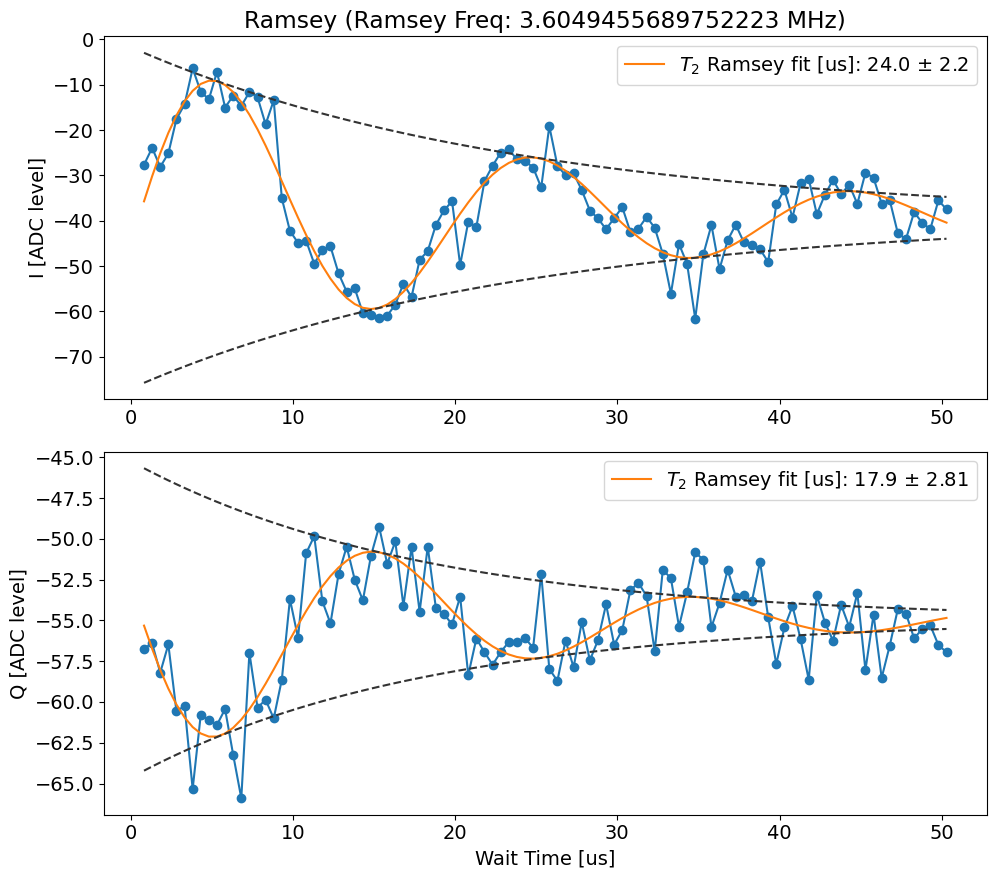

No echoes in the data
Current pi pulse frequency: 3564.2565120868453
Fit frequency from I [MHz]: 0.05092774325654074 +/- 0.0005593568005121578
Suggested new pi pulse frequency from fit I [MHz]:
 	3567.810529912564
 	3567.9123853990773
T2 Ramsey from fit I [us]: 23.975595892999944
Fit frequency from Q [MHz]: 0.05089649967160299 +/- 0.0012346424330144325
Suggested new pi pulse frequencies from fit Q [MHz]:
 	3567.810561156149
 	3567.9123541554923
T2 Ramsey from fit Q [us]: 17.890099442697633


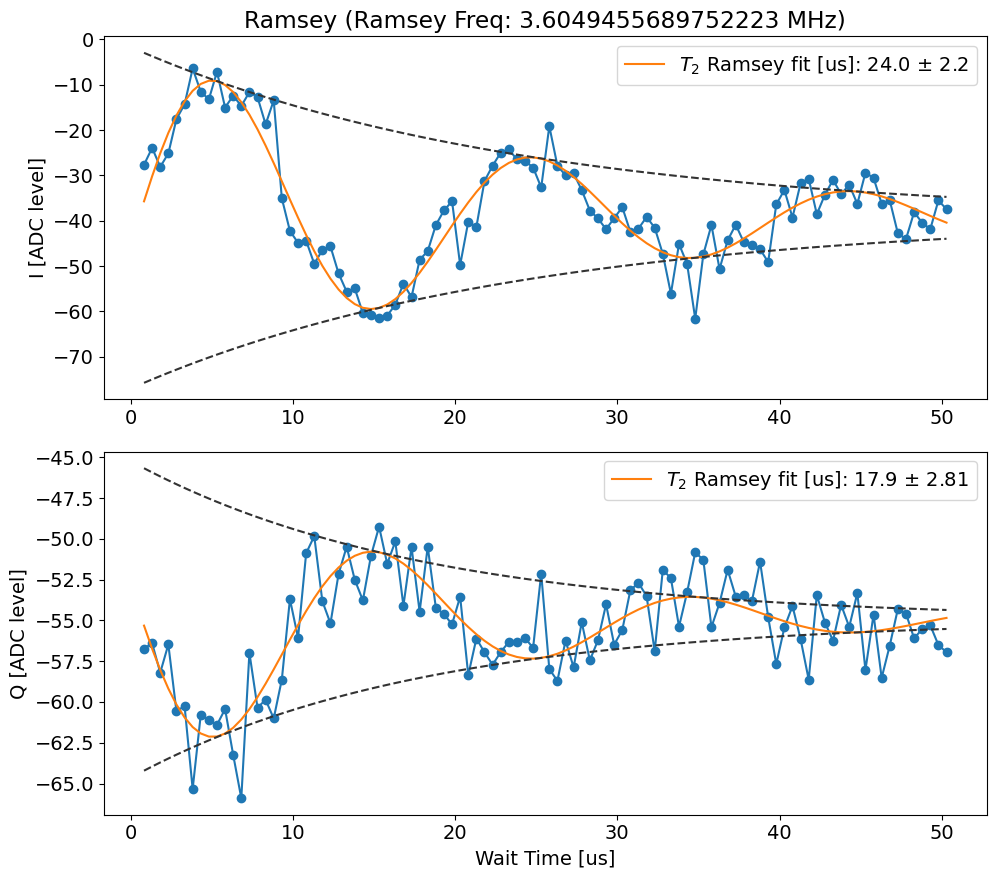

In [35]:
# 4. Execute


stark_ramsey_expt = stark_ramsey_runner.execute(
    mode='manipulate',
    man_mode_idx=1,
    start=t_start,
    step=2.5/5,
    expts=101,
    ramsey_freq=f_ramsey+0.05,             # MHz
    drive_freq=f_coupler,        # tune: detuning from the coupler feature
    drive_gain=Gain,                # sweep this by hand across runs to map the Stark shift
    rise_time=rise_time,
    reps=250,
    rounds=1,
    go_kwargs=dict(analyze=False, display=False),
    relax_delay=1000,
    # **active_reset_dict,
)

if USE_QUEUE:
    stark_ramsey_expt.analyze(fit=True)
    stark_ramsey_expt.display(fit=True)

In [22]:
# ============================================
# Sweep drive_freq; live-plot current slice (built-in RamseyFitting display)
# + running (freq, T2) extraction
# ============================================
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

# --- Sweep config ---
# f_span   = 1.0      # MHz, full span
f_npts   = 11
detuning_opt = -100*rabi_rate  # MHz, I dont have acces to g so it will be order of magnitude guess, can be optimized for better performance
f_drive = f_coupler + detuning_opt
drive_freqs = np.linspace(f_drive, f_coupler + 10, f_npts)  # MHz, sweep drive freq towards coupler feature
rabi_rate = 0.1  # MHz, target Rabi rate for the drive (adjust gain to hit this)
Gain = int(2*np.pi*rabi_rate * 2/k) # DAC gain to achieve target Rabi rate (Omega = k * Gain)
print(f'Sweeping drive frequency from {drive_freqs[0]:.3f} MHz to {drive_freqs[-1]:.3f} MHz in {f_npts} steps... compare to coupler feature at {f_coupler} MHz and target drive freq {f_drive} MHz.')

# --- Inner Ramsey config (overrides stark_ramsey_defaults) ---
inner_cfg = dict(
    mode='manipulate',
    man_mode_idx=1,
    start=0.2,
    step=2.5,
    expts=101,
    ramsey_freq=f_ramsey+0.03,             # MHz
    # drive_freq=f_coupler,        # tune: detuning from the coupler feature
    drive_gain=Gain,                # sweep this by hand across runs to map the Stark shift
    rise_time=0.05,
    # reps=250,
    reps=100,
    rounds=1,
    relax_delay=1000, 
    # go_kwargs=dict(analyze=False, display=False),
    # **active_reset_dict,
)

Sweeping drive frequency from 4085.682 MHz to 4105.682 MHz in 11 steps... compare to coupler feature at 4095.682 MHz and target drive freq 4085.682 MHz.


In [ ]:
fit_freqs, fit_T2s = [], []

for i, df in enumerate(drive_freqs):
    stark_expt = stark_ramsey_runner.execute(
        drive_freq=float(df),
        go_kwargs=dict(analyze=False, display=False),
        **inner_cfg,
    )

    # Built-in Ramsey fit: populates stark_expt.data['fit_avgi'] = [amp, freq, phase, T2, offset, ...]
    stark_expt.analyze(fit=True)
    p = stark_expt.data.get('fit_avgi')
    if isinstance(p, (list, np.ndarray)) and len(p) >= 4:
        fit_freqs.append(abs(p[1]))   # MHz
        fit_T2s.append(abs(p[3]))     # us
    else:
        fit_freqs.append(np.nan)
        fit_T2s.append(np.nan)

    # --- Redraw live ---
    clear_output(wait=True)

    # 1. Built-in per-slice Ramsey plot
    stark_expt.display(fit=True)

    # 2. Running summary: fit freq & T2 vs drive_freq
    df_arr = np.asarray(drive_freqs[:i+1])
    fig, (ax_freq, ax_t2) = plt.subplots(1, 2, figsize=(11, 4))
    ax_freq.plot(df_arr, fit_freqs, 'o-')
    # ax_freq.axhline(inner_cfg['ramsey_freq'], color='gray', ls='--', alpha=0.5,
    #                 label='virtual detune')
    ax_freq.set_xlabel('drive_freq [MHz]')
    ax_freq.set_ylabel('fit freq [MHz]')
    ax_freq.set_title(f'point {i+1}/{f_npts}  (drive_freq = {df:.2f} MHz)')
    ax_freq.legend(fontsize=8)
    ax_freq.grid(alpha=0.3)

    ax_t2.plot(df_arr, fit_T2s, 'o-', color='C1')
    ax_t2.set_xlabel('drive_freq [MHz]')
    ax_t2.set_ylabel('fit T2 [us]')
    ax_t2.grid(alpha=0.3)

    plt.tight_layout()
    display(fig)
    plt.close(fig)

# --- Final arrays for follow-up analysis ---
drive_freq_sweep = dict(
    drive_freqs=drive_freqs,
    fit_freqs=np.array(fit_freqs),
    fit_T2s=np.array(fit_T2s),
)


# Cavity-mode Ramsey with always-on Stark drive
Rings up the drive on manipulate before state prep, holds it at constant amplitude through prep + Ramsey + readout, then rings down. Only the steady-state Stark shift affects the fringe — no ramp transients near the measurement. See `experiments/single_qubit/t2_cavity_mode_stark_always_on.py`.

Key extra params vs. the segmented version:
- `stark_guard_pre` / `stark_guard_post` (us) — idle before/after the Ramsey+readout block
- `drive_hold_time` (us) — total steady-state duration; asserted ≥ prep + Ramsey + parity + readout + guards


In [30]:
f_coupler = 4095.682
k = 3.62885e-4  # rad/us/DAC, from Rabi fits
K = -57.0  # MHz, from separate measurement of the coupler's self-Kerr
rabi_rate = 0.1  # MHz, target Rabi rate for the drive (adjust gain to hit this)
Gain = int(2*np.pi*rabi_rate * 2/k) # DAC gain to achieve target Rabi rate (Omega = k * Gain)
detuning_opt = -1000*rabi_rate  # MHz, I dont have acces to g so it will be order of magnitude guess, can be optimized for better performance
f_drive = f_coupler + detuning_opt  # MHz, drive frequency detuned from coupler feature
f_ramsey = 3.5779952741678973 - 0.023049705192674724 # MHz, from Ramsey fit (should be close to f_drive - f_coupler)
rise_time = 0.2  # us
t_start = 4 * rise_time  # us, must be >= 4 * rise_time to ensure the flat-top portion of the drive exists at the shortest Ramsey time


print(f'For a drive detuned by {detuning_opt} MHz from the coupler feature at {f_coupler} MHz,')
print(f'with a self-Kerr of {K} MHz, to achieve a Rabi rate of {rabi_rate} MHz, you would set the drive frequency to {f_drive} MHz and the gain to {Gain} DAC units.')  


For a drive detuned by -100.0 MHz from the coupler feature at 4095.682 MHz,
with a self-Kerr of -57.0 MHz, to achieve a Rabi rate of 0.1 MHz, you would set the drive frequency to 3995.682 MHz and the gain to 3462 DAC units.


In [31]:
# ============================================
# T2 cavity-mode Ramsey with ALWAYS-ON Stark drive on manipulate
# rise  ->  guard_pre  ->  prep  ->  pi/2  ->  wait  ->  pi/2  ->  parity  ->  readout  ->  guard_post  ->  fall
# Drive at constant amplitude throughout the prep+Ramsey+readout block.
# ============================================

# 1. Defaults
stark_ao_defaults = AttrDict(dict(
    # Ramsey target mode
    mode='manipulate',
    man_mode_idx=1,
    man_mode_no=1,
    # Wait-time sweep [us]
    start=0.2,
    step=0.5,
    expts=41,
    ramsey_freq=0.5,
    # Stark drive on manipulate (fixed across the sweep)
    drive_freq=4100.0,
    drive_gain=0,                # start at 0 to recover undriven baseline
    rise_time=0.2,              # us per-edge (sigma = rise_time/2)
    stark_guard_pre=5.0,         # us: idle after rise, before prep
    stark_guard_post=5.0,        # us: idle after readout, before fall
    # Averaging
    reps=200,
    rounds=1,
    qubits=[0],
    # Echo / parity / reset / custom pulses
    echoes=0,
    parity_meas=True,
    prepulse=False,
    pre_sweep_pulse=None,
    postpulse=False,
    post_sweep_pulse=None,
    active_reset=False,
))


# 2. Optional postprocessor
def stark_ao_postproc(station, expt):
    expt.analyze(fit=True)
    expt.display(fit=True)
    return None


# 3. Runner
stark_ao_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.CavityModeStarkAlwaysOnExperiment,
    default_expt_cfg=stark_ao_defaults,
    postprocessor=stark_ao_postproc,
    job_client=client,
    use_queue=USE_QUEUE,
)


Job submitted: JOB-20260423-00222 (queue position: 1)

[0.1s] Job JOB-20260423-00222: pending

[60.5s] Job JOB-20260423-00222: running
[WORKER] Loading CavityModeStarkAlwaysOnExperiment from experiments.single_qubit.t2_cavity_mode_stark_always_on
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260423-00222_CavityModeStarkAlwaysOnExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
[CavityModeStarkAlwaysOn] drive_hold_time = 61.74 us  (estimate 56.74 + margin 5.00) at longest wait = 50.80 us
  breakdown [us]: guard_pre=1.0, prep=0.00, pi/2 x2=1.13, wait=50.80, echo=0.00, post=0.00, parity=1.60, readout=1.20, guard_post=1.0
100%|████████████████████████████████████████| 101/101 [00:46<00:00,  2.19it/s]
No echoes in the data

[112.9s] Job JOB-20260423-00222: completed
Saving D:\experiments\260420_T2_AC_stark\data\JOB-20260423-00222_CavityModeStarkAlwaysOnExperim

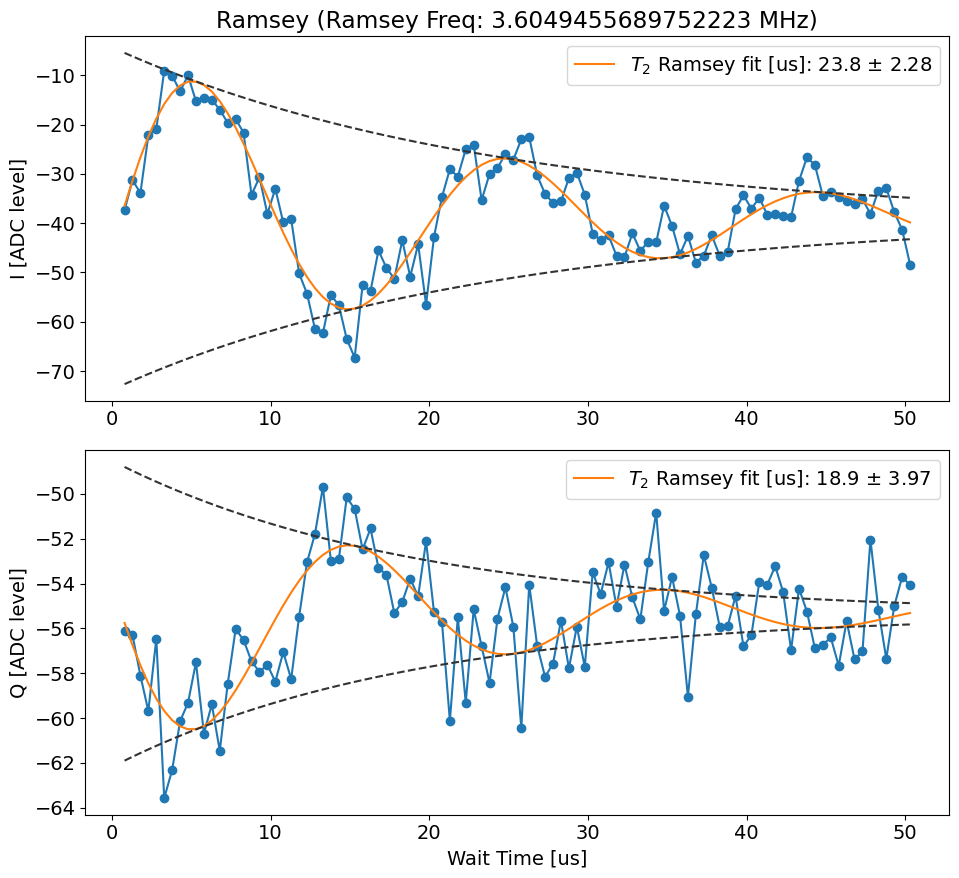

No echoes in the data
Current pi pulse frequency: 3564.2565120868453
Fit frequency from I [MHz]: 0.05087253952666155 +/- 0.0005857445251243831
Suggested new pi pulse frequency from fit I [MHz]:
 	3567.810585116294
 	3567.9123301953473
T2 Ramsey from fit I [us]: 23.822761679687407
Fit frequency from Q [MHz]: 0.050556173841279764 +/- 0.001562341357462239
Suggested new pi pulse frequencies from fit Q [MHz]:
 	3567.8109014819793
 	3567.9120138296616
T2 Ramsey from fit Q [us]: 18.859966528548455


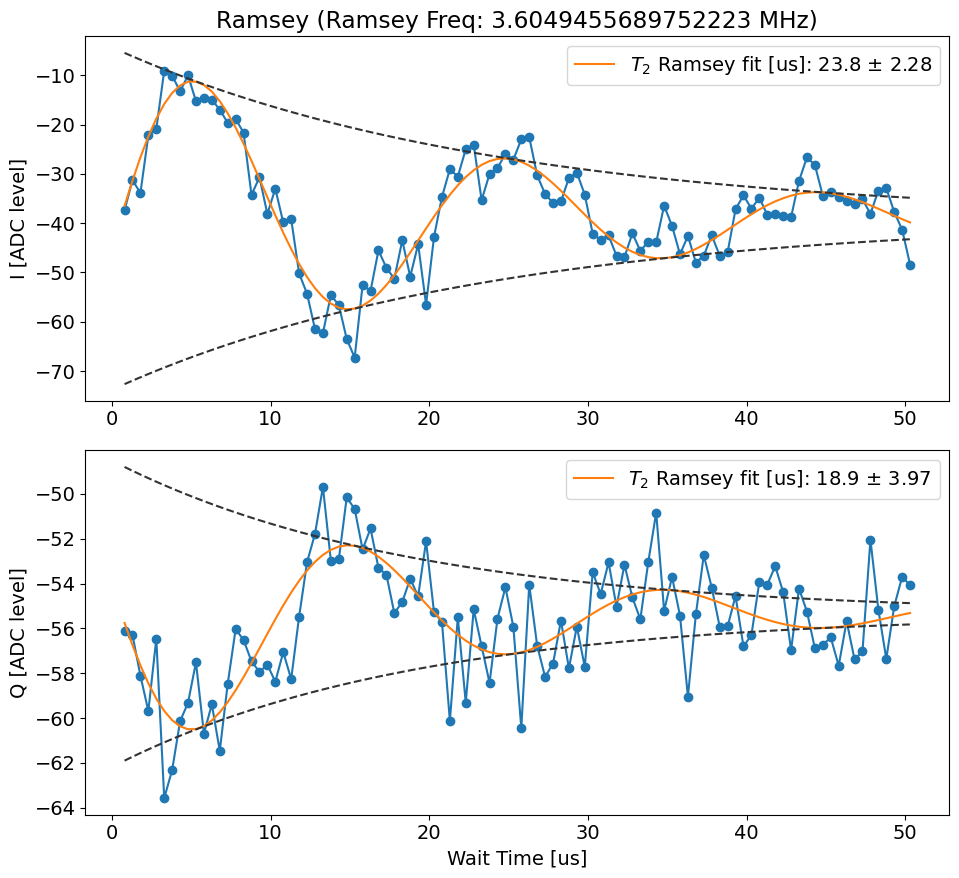

In [37]:
# 4. Execute — single run at one drive_freq / drive_gain
stark_ao_expt = stark_ao_runner.execute(
    mode='manipulate',
    man_mode_idx=1,

    start=t_start,
    step=2.5/5,
    expts=101,
    ramsey_freq=f_ramsey+0.05,             # MHz
    drive_freq=f_coupler,        # tune: detuning from the coupler feature
    drive_gain=Gain,                # sweep this by hand across runs to map the Stark shift
    rise_time=rise_time,
    reps=250,
    stark_guard_pre=1.0,
    stark_guard_post=1.0,
    rounds=1,
    go_kwargs=dict(analyze=False, display=False),
    # **active_reset_dict,
    relax_delay=1000,
)

if USE_QUEUE:
    stark_ao_expt.analyze(fit=True)
    stark_ao_expt.display(fit=True)


In [ ]:
# ============================================
# Sweep drive_freq; live-plot current slice (built-in RamseyFitting display)
# + running (freq, T2) extraction
# ============================================
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

# --- Sweep config ---
# f_span   = 1.0      # MHz, full span
f_npts   = 11
detuning_opt = -100*rabi_rate  # MHz, I dont have acces to g so it will be order of magnitude guess, can be optimized for better performance
f_drive = f_coupler + detuning_opt
drive_freqs = np.linspace(f_drive, f_coupler + 10, f_npts)  # MHz, sweep drive freq towards coupler feature
rabi_rate = 0.1  # MHz, target Rabi rate for the drive (adjust gain to hit this)
Gain = int(2*np.pi*rabi_rate * 2/k) # DAC gain to achieve target Rabi rate (Omega = k * Gain)
print(f'Sweeping drive frequency from {drive_freqs[0]:.3f} MHz to {drive_freqs[-1]:.3f} MHz in {f_npts} steps... compare to coupler feature at {f_coupler} MHz and target drive freq {f_drive} MHz.')


# --- Inner Ramsey config (overrides stark_ramsey_defaults) ---
inner_cfg = dict(
    mode='manipulate',
    man_mode_idx=1,
    start=0.2,
    step=2.5,
    expts=101,
    ramsey_freq=f_ramsey+0.03,             # MHz
    # drive_freq=f_coupler,        # tune: detuning from the coupler feature
    drive_gain=Gain,                # sweep this by hand across runs to map the Stark shift
    rise_time=0.05,
    # reps=250,
    reps=100,
    rounds=1,
    relax_delay=1000,
    # go_kwargs=dict(analyze=False, display=False),
    # **active_reset_dict,
)

In [ ]:
fit_freqs, fit_T2s = [], []

for i, df in enumerate(drive_freqs):
    stark_expt = stark_ao_runner.execute(
        drive_freq=float(df),
        go_kwargs=dict(analyze=False, display=False),
        **inner_cfg,
    )

    # Built-in Ramsey fit: populates stark_expt.data['fit_avgi'] = [amp, freq, phase, T2, offset, ...]
    stark_expt.analyze(fit=True)
    p = stark_expt.data.get('fit_avgi')
    if isinstance(p, (list, np.ndarray)) and len(p) >= 4:
        fit_freqs.append(abs(p[1]))   # MHz
        fit_T2s.append(abs(p[3]))     # us
    else:
        fit_freqs.append(np.nan)
        fit_T2s.append(np.nan)

    # --- Redraw live ---
    clear_output(wait=True)

    # 1. Built-in per-slice Ramsey plot
    stark_expt.display(fit=True)

    # 2. Running summary: fit freq & T2 vs drive_freq
    df_arr = np.asarray(drive_freqs[:i+1])
    fig, (ax_freq, ax_t2) = plt.subplots(1, 2, figsize=(11, 4))
    ax_freq.plot(df_arr, fit_freqs, 'o-')
    # ax_freq.axhline(inner_cfg['ramsey_freq'], color='gray', ls='--', alpha=0.5,
    #                 label='virtual detune')
    ax_freq.set_xlabel('drive_freq [MHz]')
    ax_freq.set_ylabel('fit freq [MHz]')
    ax_freq.set_title(f'point {i+1}/{f_npts}  (drive_freq = {df:.2f} MHz)')
    ax_freq.legend(fontsize=8)
    ax_freq.grid(alpha=0.3)

    ax_t2.plot(df_arr, fit_T2s, 'o-', color='C1')
    ax_t2.set_xlabel('drive_freq [MHz]')
    ax_t2.set_ylabel('fit T2 [us]')
    ax_t2.grid(alpha=0.3)

    plt.tight_layout()
    display(fig)
    plt.close(fig)

# --- Final arrays for follow-up analysis ---
drive_freq_sweep = dict(
    drive_freqs=drive_freqs,
    fit_freqs=np.array(fit_freqs),
    fit_T2s=np.array(fit_T2s),
)
